# Hidden Markov models: from a binned trace to rates

A trace that steps between levels — a molecule folding, a dye blinking, a
complex binding — carries kinetics that no histogram of its intensities can
recover. Thresholding by eye gives a state path with no error bars and no
defensible number of states. A hidden Markov model gives both.

This notebook runs the whole loop on data whose answer is known, so every
number can be checked against what went in:

1. **simulate** a three-state trace with chosen rates;
2. **choose the number of states** by BIC — not by eye, and not by the
   likelihood, which always prefers more;
3. **fit and decode**, and compare states, dwell times and rates with the truth;
4. **fit several traces jointly**, the way repeats of one experiment are handled;
5. **watch it fail** — too many states, and bins too coarse for the kinetics.

Theory: *Concepts → Hidden Markov models of binned traces*. GUI: *Guides →
Hidden Markov models of binned traces*. The estimator is
`chisurf.core.math.hmm`; everything below goes through the shared analysis in
`chisurf.plugins.core.hmm.core`, which is what the GUI, the CLI and the RPC
service use as well.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from chisurf.core.math.hmm import GaussianHMM
from chisurf.plugins.core.hmm.api import HmmSettings
from chisurf.plugins.core.hmm.core import dwell_times, fit_traces, scan_state_counts

plt.rcParams["figure.dpi"] = 110

## 1. Simulate a trace with known kinetics

Three states, one detection channel, 1 ms bins. The rate matrix is what we
want back at the end, so it is written down explicitly and converted to
per-bin transition probabilities with $A \approx I + K\,\Delta t$ — the same
short-bin approximation the analysis inverts later.

In [2]:
BIN = 1e-3  # s
N_BINS = 30_000

MEANS = np.array([12.0, 34.0, 60.0])  # counts per bin
SIGMA = 4.0

# k[i, j] = rate from state i to state j, in 1/s
RATES = np.array(
    [
        [0.0, 20.0, 2.0],
        [15.0, 0.0, 25.0],
        [1.0, 30.0, 0.0],
    ]
)

transmat = RATES * BIN
np.fill_diagonal(transmat, 1.0 - transmat.sum(axis=1))

rng = np.random.default_rng(1)
truth_states = np.zeros(N_BINS, dtype=int)
for t in range(1, N_BINS):
    truth_states[t] = rng.choice(3, p=transmat[truth_states[t - 1]])
trace = MEANS[truth_states] + rng.normal(0, SIGMA, N_BINS)

print(f"{N_BINS} bins of {BIN * 1e3:.0f} ms = {N_BINS * BIN:.1f} s")
print("occupancy:", np.round(np.bincount(truth_states) / N_BINS, 3))

30000 bins of 1 ms = 30.0 s
occupancy: [0.268 0.408 0.324]


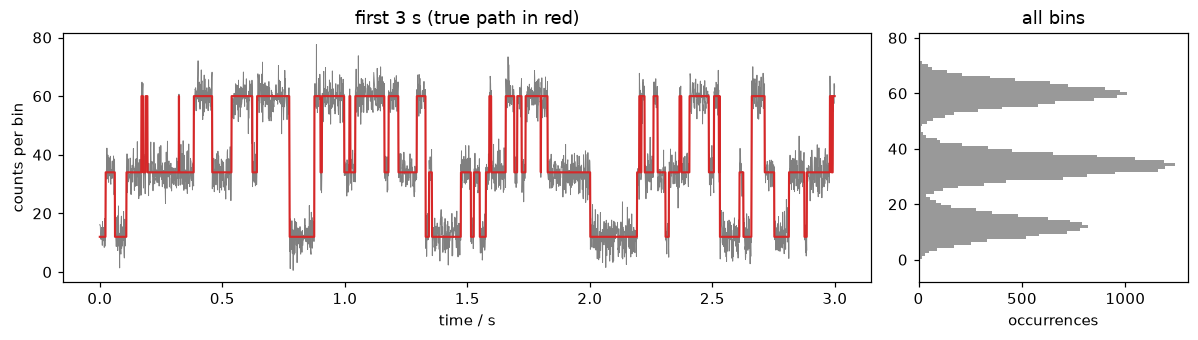

In [3]:
fig, (ax_trace, ax_hist) = plt.subplots(
    1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [3, 1]}
)
time = np.arange(N_BINS) * BIN
show = slice(0, 3000)
ax_trace.plot(time[show], trace[show], lw=0.6, color="0.5")
ax_trace.plot(time[show], MEANS[truth_states][show], lw=1.4, color="C3")
ax_trace.set(xlabel="time / s", ylabel="counts per bin", title="first 3 s (true path in red)")
ax_hist.hist(trace, bins=80, orientation="horizontal", color="0.6")
ax_hist.set(xlabel="occurrences", title="all bins")
fig.tight_layout()

The histogram shows three levels, but two of them nearly touch: with
$\sigma = 4$ counts and means 12 apart there is real overlap. That is the
regime where an HMM earns its keep — it separates the states by *when* they
occur, not only by how bright they are.

## 2. How many states?

The likelihood improves with every state added, so it cannot choose. Fit a
range of state counts and compare information criteria, which charge for
parameters. `scan_state_counts` does exactly that and reports the minimum.

In [4]:
scan = scan_state_counts(trace, HmmSettings(time_step=BIN), min_states=1, max_states=6)

for n, ll, aic, bic in zip(scan.n_states, scan.log_likelihood, scan.aic, scan.bic):
    print(f"{n} states: log L = {ll:12.1f}   AIC = {aic:11.1f}   BIC = {bic:11.1f}")
print(f"\nBIC prefers {scan.best_bic} states, AIC {scan.best_aic}.")

1 states: log L =    -130773.7   AIC =    261551.5   BIC =    261568.1
2 states: log L =    -108231.5   AIC =    216477.1   BIC =    216535.2
3 states: log L =     -88534.2   AIC =    177096.5   BIC =    177212.8
4 states: log L =     -88530.8   AIC =    177107.6   BIC =    177298.7
5 states: log L =     -88526.1   AIC =    177120.2   BIC =    177402.7
6 states: log L =     -88524.9   AIC =    177143.7   BIC =    177534.2

BIC prefers 3 states, AIC 3.


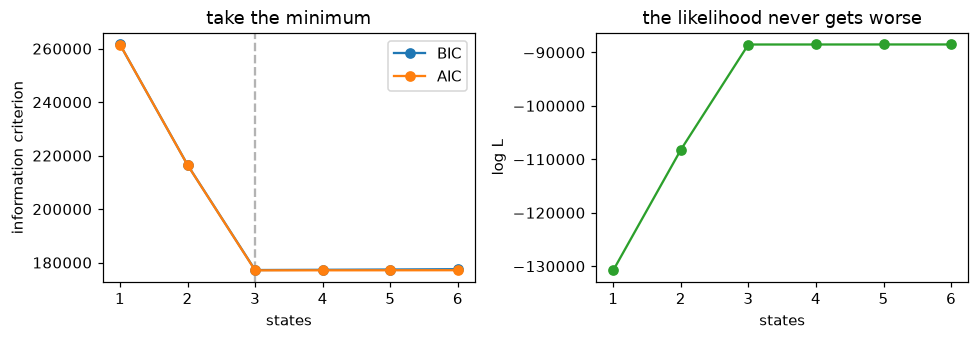

In [5]:
fig, (ax_ic, ax_ll) = plt.subplots(1, 2, figsize=(9, 3.2))
ax_ic.plot(scan.n_states, scan.bic, "o-", label="BIC")
ax_ic.plot(scan.n_states, scan.aic, "o-", label="AIC")
ax_ic.axvline(scan.best_bic, color="0.7", ls="--", zorder=0)
ax_ic.set(xlabel="states", ylabel="information criterion", title="take the minimum")
ax_ic.legend()
ax_ll.plot(scan.n_states, scan.log_likelihood, "o-", color="C2")
ax_ll.set(xlabel="states", ylabel="log L", title="the likelihood never gets worse")
fig.tight_layout()

The right panel is the reason for the left one: the log-likelihood keeps
climbing past the truth, while BIC turns around at three. Read the *minimum*
of the criterion, not the elbow of the likelihood.

A criterion still falling at the edge of the range is evidence against the
model rather than for many states — bleaching, drift, or a continuum of
states will all look like that.

## 3. Fit and decode

In [6]:
fit = fit_traces(trace, HmmSettings(n_states=scan.best_bic, time_step=BIN))

print(f"log L = {fit.log_likelihood:,.1f}   BIC = {fit.bic:,.1f}")
print(f"converged: {fit.converged} after {fit.n_iterations} iterations\n")
print("state   mean    std   occupancy   visits   mean dwell / ms")
for s in fit.summaries:
    print(
        f"{s.index:5d} {s.mean[0]:7.2f} {s.std[0]:6.2f} {s.occupancy:11.3f} "
        f"{s.n_dwells:8d} {s.mean_dwell * 1e3:16.2f}"
    )

log L = -88,534.2   BIC = 177,212.8
converged: True after 2 iterations

state   mean    std   occupancy   visits   mean dwell / ms
    0   12.02   3.98       0.268      170            47.26
    1   33.91   4.01       0.408      432            28.33
    2   59.98   4.00       0.324      293            33.20


States come back ordered **dimmest first**, always. EM itself labels them
arbitrarily; the shared analysis relabels so that "state 0" means the same
thing in every fit, table and figure — which is what makes two runs, or two
tools, comparable at all.

So the recovered means can be compared with the truth directly:

In [7]:
recovered = np.array([s.mean[0] for s in fit.summaries])
print("true means     ", np.round(MEANS, 2))
print("recovered means", np.round(recovered, 2))
print("true σ         ", SIGMA)
print("recovered σ    ", np.round([s.std[0] for s in fit.summaries], 2))

states = fit.state_array
print(f"\nper-bin agreement with the true path: {np.mean(states == truth_states):.4f}")

true means      [12. 34. 60.]
recovered means [12.02 33.91 59.98]
true σ          4.0
recovered σ     [3.98 4.01 4.  ]

per-bin agreement with the true path: 0.9999


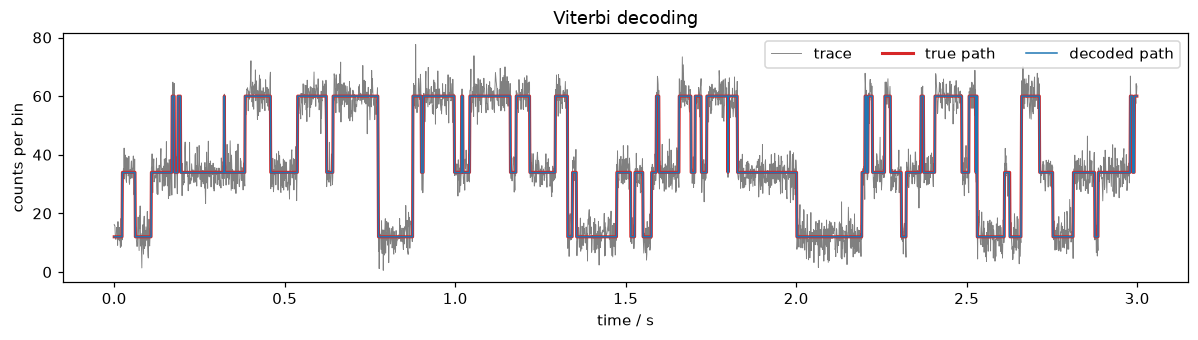

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(time[show], trace[show], lw=0.6, color="0.5", label="trace")
ax.plot(time[show], MEANS[truth_states][show], lw=2.0, color="C3", label="true path")
ax.plot(time[show], recovered[states][show], lw=1.0, color="C0", label="decoded path")
ax.set(xlabel="time / s", ylabel="counts per bin", title="Viterbi decoding")
ax.legend(loc="upper right", ncol=3)
fig.tight_layout()

### Rates

The transition matrix is per *bin*; dividing by the bin width gives rates.
`fit.transition_rates` has already done that, with the diagonal set to the
negative row sum so the matrix reads as a generator.

In [9]:
recovered_rates = np.array(fit.transition_rates)
print("true rates (1/s):")
print(np.round(RATES, 1))
print("\nrecovered rates (1/s):")
print(np.round(np.where(np.eye(3, dtype=bool), 0.0, recovered_rates), 1))

true rates (1/s):
[[ 0. 20.  2.]
 [15.  0. 25.]
 [ 1. 30.  0.]]

recovered rates (1/s):
[[ 0.  19.4  1.9]
 [12.6  0.  22.7]
 [ 1.6 28.5  0. ]]


### Dwell times

A Markov state leaves exponentially distributed dwell times, so the histogram
is a straight line on a logarithmic count axis with slope $-k_i$, the total
exit rate. **Curvature is the single most useful diagnostic in this analysis**:
it says the level hides more than one state.

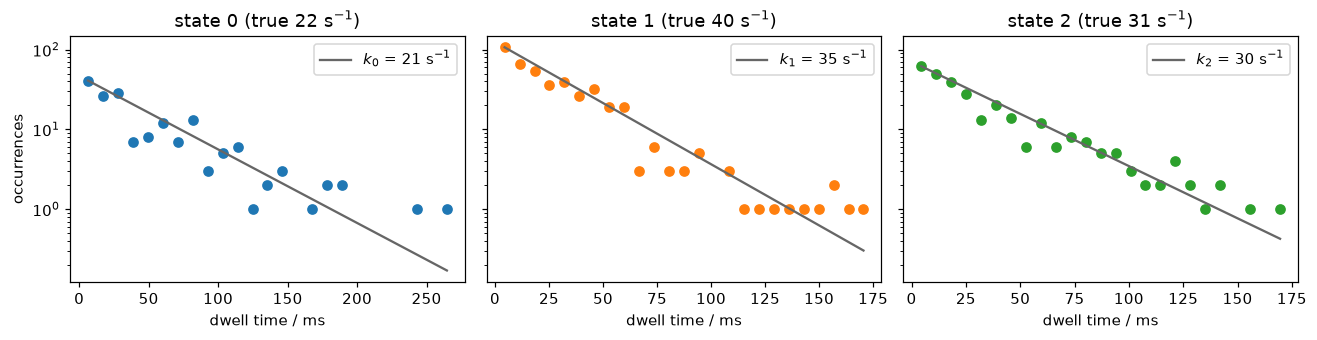

In [10]:
dwells = dwell_times(states, time_step=BIN)
exit_rates = -np.diagonal(recovered_rates)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for s, ax in enumerate(axes):
    durations = np.asarray(dwells[s]) * 1e3  # ms
    counts, edges = np.histogram(durations, bins=25)
    centres = 0.5 * (edges[:-1] + edges[1:])
    ax.semilogy(centres, counts, "o", color=f"C{s}")
    model = counts.max() * np.exp(-(centres - centres[0]) * exit_rates[s] * 1e-3)
    ax.semilogy(centres, model, "-", color="0.4",
                label=f"$k_{{{s}}}$ = {exit_rates[s]:.0f} s$^{{-1}}$")
    true_exit = RATES[s].sum()
    ax.set(xlabel="dwell time / ms", title=f"state {s} (true {true_exit:.0f} s$^{{-1}}$)")
    ax.legend()
axes[0].set_ylabel("occurrences")
fig.tight_layout()

## 4. Several traces at once

Repeats of one experiment are fitted **jointly as separate sequences**: they
share one set of states and transitions, but no transition is ever counted
across the seam between two traces — the gap between them is not observed
time. Pass a list; `lengths` comes back so the concatenated state path can be
split again.

In [11]:
def simulate(n_bins, seed):
    """Return one binned trace from the same three-state model."""
    local = np.random.default_rng(seed)
    path = np.zeros(n_bins, dtype=int)
    for t in range(1, n_bins):
        path[t] = local.choice(3, p=transmat[path[t - 1]])
    return MEANS[path] + local.normal(0, SIGMA, n_bins)


repeats = [simulate(n, seed) for n, seed in ((6000, 11), (9000, 12), (4000, 13))]
joint = fit_traces(repeats, HmmSettings(n_states=3, time_step=BIN))

print("lengths:", joint.lengths)
print("means:  ", np.round([s.mean[0] for s in joint.summaries], 2))

per_trace = np.split(joint.state_array, np.cumsum(joint.lengths)[:-1])
for i, path in enumerate(per_trace):
    print(f"trace {i}: {len(path)} bins, occupancy "
          f"{np.round(np.bincount(path, minlength=3) / len(path), 3)}")

lengths: [6000, 9000, 4000]
means:   [11.89 34.03 60.05]
trace 0: 6000 bins, occupancy [0.271 0.418 0.311]
trace 1: 9000 bins, occupancy [0.215 0.451 0.335]
trace 2: 4000 bins, occupancy [0.351 0.41  0.238]


## 5. Two ways to get it wrong

### Too many states

Ask for six and the extra states do not vanish — they split real ones, or
collect noise. They show up as tiny occupancies and dwell times of a bin or
two, which is what to look for when the BIC scan was skipped.

In [12]:
too_many = fit_traces(trace, HmmSettings(n_states=6, time_step=BIN))
print("state   mean   occupancy   mean dwell / ms")
for s in too_many.summaries:
    print(f"{s.index:5d} {s.mean[0]:7.2f} {s.occupancy:11.4f} {s.mean_dwell * 1e3:15.2f}")
print(f"\nBIC: {too_many.bic:,.0f} against {fit.bic:,.0f} for three states "
      f"(higher is worse)")

state   mean   occupancy   mean dwell / ms
    0   10.58      0.1495            2.46
    1   13.60      0.1183            1.97
    2   32.46      0.1868            1.27
    3   35.21      0.2212            1.52
    4   58.61      0.1382            1.63
    5   61.23      0.1860            2.20

BIC: 177,534 against 177,213 for three states (higher is worse)


### Bins too coarse for the kinetics

Nothing faster than one bin is visible. Rebinning by 20 (to 20 ms) puts
several transitions inside a single bin: the fast pair of states blurs into
one intermediate level, and the rates that survive are underestimated because
$A_{ij}$ is no longer small.

In [13]:
FACTOR = 20
coarse = trace[: N_BINS // FACTOR * FACTOR].reshape(-1, FACTOR).mean(axis=1)
coarse_fit = fit_traces(coarse, HmmSettings(n_states=3, time_step=BIN * FACTOR))

print(f"bin width {BIN * FACTOR * 1e3:.0f} ms")
print("means:", np.round([s.mean[0] for s in coarse_fit.summaries], 2),
      " (true", np.round(MEANS, 1), ")")
coarse_exit = -np.diagonal(np.array(coarse_fit.transition_rates))
print("exit rates:", np.round(coarse_exit, 1),
      " (true", np.round(RATES.sum(axis=1), 1), ")")

bin width 20 ms
means: [12.11 36.15 59.75]  (true [12. 34. 60.] )
exit rates: [13.8 10.6 19.3]  (true [22. 40. 31.] )


Binning coarsely enough for the Gaussian emission approximation while finely
enough for the rates is the real experimental trade-off in this analysis. When
the photons will not support a fine enough bin, stop binning altogether and
use **H2MM**, which works photon by photon.

## The estimator directly

Everything above went through the shared analysis, which is the right entry
point for a measurement. The estimator underneath is a plain scikit-learn-shaped
object, useful when you want the model itself — to score new data, sample from
it, or hold parameters fixed.

Note what it does *not* do: its state labels are whatever EM produced. That is
exactly the job the shared analysis takes off your hands, and the reason to
prefer it whenever a result will be read by a person or compared with another
fit.

In [14]:
model = GaussianHMM(n_components=3, covariance_type="full", random_state=0)
model.fit(trace[:, None])

print("means in the model's own label order:", np.round(model.means_.ravel(), 2))
print("log L:      ", round(model.score(trace[:, None]), 1))
print("BIC:        ", round(model.bic(trace[:, None]), 1))
print("stationary: ", np.round(model.get_stationary_distribution(), 3))

sampled, sampled_states = model.sample(5, random_state=3)
print("\nfive samples drawn from the fitted model:")
for value, state in zip(sampled.ravel(), sampled_states):
    print(f"  {value:6.2f} counts from state {state} (mean {model.means_[state, 0]:.1f})")

means in the model's own label order: [33.91 59.98 12.02]
log L:       -88534.2
BIC:         177212.8
stationary:  [0.409 0.325 0.267]

five samples drawn from the fitted model:
   11.17 counts from state 2 (mean 12.0)
    3.98 counts from state 2 (mean 12.0)
   11.10 counts from state 2 (mean 12.0)
    8.58 counts from state 2 (mean 12.0)
   25.25 counts from state 2 (mean 12.0)


## Where else this lives

* **GUI** — *Analysis → Kinetics → Hidden Markov model*, same analysis, same
  plots.
* **CLI** — `csc hmm fit trace.csv --states 3 --time-step 1e-3 -o fit.json`,
  and `csc hmm scan` for the state-count scan.
* **RPC** — `hmm.fit` and `hmm.scan` return the JSON form of the objects used
  above.

For photon-by-photon kinetics without binning see the H2MM plugin; for an
empirical-Bayes treatment of many short FRET traces, ebFRET.